# 06 — Lift and gains

This project uses synthetic data inspired by common online gaming analytics use cases. It does not contain confidential or proprietary Junglee Games data.

The retention desk cannot call the whole active base. Decile 1 is the 10% of June players with the highest predicted probability. Capture and lift are computed here from the saved champion probabilities.


In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import os
os.chdir(ROOT)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Project root:", ROOT)


Project root: /workspace/player-churn-prediction


In [2]:
from src.evaluation import capture_at_fractions, decile_lift

preds = pd.read_csv(ROOT / "reports/model_metrics/test_predictions.csv")
y = preds["y_true"].to_numpy()
p = preds["p_champion"].to_numpy()
lift = decile_lift(y, p)
capture = capture_at_fractions(y, p, [0.05, 0.10, 0.20])
display(lift)
display(capture)
base = float(y.mean())
top = lift.iloc[0]
at10 = capture.loc[capture["contact_fraction"] == 0.10].iloc[0]
display(Markdown(
    f"Base churn is **{base:.1%}**. The top decile churns at **{top['churn_rate']:.1%}** "
    f"(lift **{top['lift']:.2f}x**) and holds **{top['cumulative_churn_capture']:.1%}** of all churners. "
    f"Contacting the top 10% captures **{at10['recall_at_k']:.1%}** of churners "
    f"at **{at10['precision_at_k']:.1%}** precision, lift **{at10['lift']:.2f}x**. "
    f"An accuracy of {(1-base):.0%} from ignoring the problem catches **none** of them. "
    "That is why the operating conversation is lift at a contact cap, not a single accuracy number."
))


,decile,users,churners,churn_rate,cumulative_churn_capture,lift
0,1,7116,2953,0.4150,0.1918,1.9178
1,2,7116,2746,0.3859,0.3701,1.7833
2,3,7117,2492,0.3501,0.5319,1.6182
3,4,7116,1848,0.2597,0.6519,1.2001
4,5,7117,1924,0.2703,0.7769,1.2493
5,6,7116,1070,0.1504,0.8464,0.6949
6,7,7116,937,0.1317,0.9072,0.6085
7,8,7117,641,0.0901,0.9488,0.4162
8,9,7116,420,0.0590,0.9761,0.2728
9,10,7117,368,0.0517,1.0000,0.2390


,contact_fraction,users_contacted,churners_captured,precision_at_k,recall_at_k,lift
0,0.0500,3558,1530,0.4300,0.0994,1.9873
1,0.1000,7116,2953,0.4150,0.1918,1.9178
2,0.2000,14233,5699,0.4004,0.3701,1.8504


Base churn is **21.6%**. The top decile churns at **41.5%** (lift **1.92x**) and holds **19.2%** of all churners. Contacting the top 10% captures **19.2%** of churners at **41.5%** precision, lift **1.92x**. An accuracy of 78% from ignoring the problem catches **none** of them. That is why the operating conversation is lift at a contact cap, not a single accuracy number.

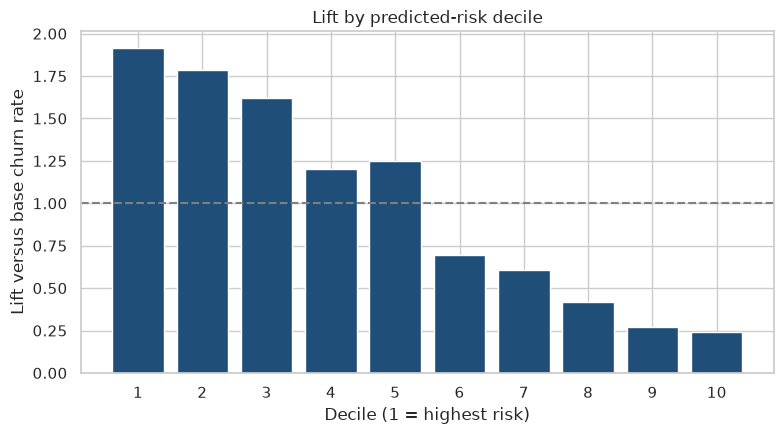

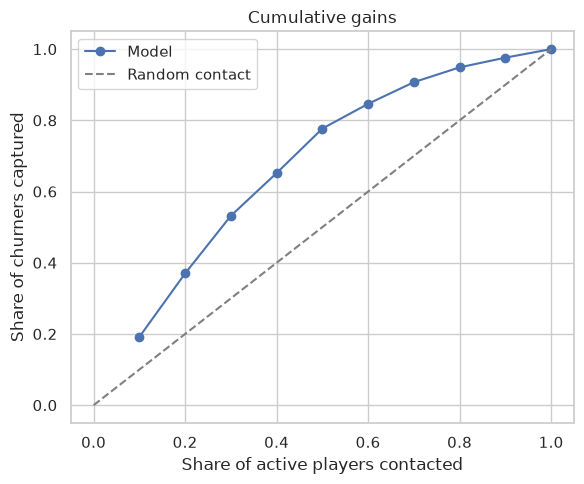

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(lift["decile"].astype(str), lift["lift"], color="#1f4e79")
ax.axhline(1.0, color="grey", linestyle="--")
ax.set_title("Lift by predicted-risk decile")
ax.set_xlabel("Decile (1 = highest risk)")
ax.set_ylabel("Lift versus base churn rate")
fig.tight_layout()
fig.savefig(ROOT / "reports/figures/lift_by_decile_notebook.png", dpi=140)
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
share = np.arange(1, 11) / 10
ax.plot(share, lift["cumulative_churn_capture"], marker="o", label="Model")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random contact")
ax.set_title("Cumulative gains")
ax.set_xlabel("Share of active players contacted")
ax.set_ylabel("Share of churners captured")
ax.legend()
fig.tight_layout()
fig.savefig(ROOT / "reports/figures/cumulative_gains_notebook.png", dpi=140)
plt.show()
